# Day 2- Quantum Error Correction Technique: Phase Flip Code
Priviously we seen 3 Qubit Bit-flip code quantum error correction technique.In this notebook we will see the Phase flip code and how to apply this as quantum error correction.In this Notebooke Cover Below Points:
- Key Idea
- Introduction to Phase flip error
- Encoding qubit against error
- what is Phase flip Error
- convert phase error into bit error
- Syndrome measurement
- Correction
- complete phase flip circuit
- Run circuit on simulator
- comparision with no error correction
- Visualization : final comparision graph
- Test all three possible locations
Let's deep dive into phase flip code and its implemenation using qiskit.

Quantum computer are highly sensitive to to noise.During the quantum computation ,a qubit can experienece a different types of errors. The two basic Pauli errors are :

X =$\begin{bmatrix} 0 & 1\\ 1 & 0 \end{bmatrix}$
    
Y =$\begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix}$
- **Bit Flip Error(X)** - change $|0\rangle \rightarrow |1\rangle $ and vice versa.
- **Phase Flip Error(Z)** - Change the relative  Phase : $|0\rangle \rightarrow |0\rangle $ and $|1\rangle \rightarrow |-1\rangle $ 

For General Qubit State: $|\psi\rangle= \alpha |0\rangle + \beta |1\rangle $

while Phase Flip Introduced :  $Z|\psi\rangle= \alpha |0\rangle - \beta |1\rangle$

In the privious notebook ,we used 3-Qubit Bit Flip Code to protect against an X-error.Here we will construct analogeous 3-Qubit phase flip code which protect against a single Z error.

### What is a Key idea?
The phase flip code uses a hadamard basis .Recall 
-  $|+\rangle= \frac{\alpha |0\rangle + \beta |1\rangle}{\sqrt{2}}$    and  $|-\rangle= \frac{\alpha |0\rangle - \beta |1\rangle}{\sqrt{2}}$ 

The important Observation is:
$Z|+\rangle = |-\rangle$  and $Z|-\rangle= |+\rangle$
Therefore,in the X-basis , a phase flip behave like **bit flip**. this gives us very useful trick -**Convert the phase-flip problem into bit-flip problem using the hadamard gate**

So,overall structure becomes:
$ H \rightarrow 3-Qubit Bit-flip Code \rightarrow Z-error \rightarrow bit-flip correction \rightarrow H $

lets Explore step by step Qiskit implemetation

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
import numpy as np
import matplotlib.pyplot as plt
from qiskit.visualization  import plot_histogram

## Step 1 - Understand Phase-Flip Error First
To visualizing a Phase flip  ,consider :
$|+\rangle=\frac{|0\rangle +|1\rangle}{\sqrt{2}}$

After Applying Z : $Z|+\rangle=\frac{|0\rangle -|1\rangle}{\sqrt{2}} = |-\rangle$

But the probabilities of measuring 0 and 1 are still :
$P(0)=P(1)=\frac{1}{2}$

So Phase flip is **not directly visisble from computational-basis probabilities.** This is an important difference between  from Bit-Flip Error.


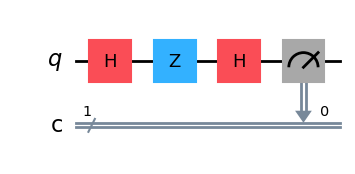

In [71]:
qc_phase= QuantumCircuit(1,1)
# Prepare |->
qc_phase.h(0)
# Apply phase Flip
qc_phase.z(0)
# convert back to computation Basis
qc_phase.h(0)
#Measure
qc_phase.measure(0,0)
qc_phase.draw("mpl")

Let Run the circuit on simulator ,we should obtained approximatly : count for state |1> :1024 .the exactly result should be deterministic for this ideal ciruit.

## Encoding a Qubit Against Phase Error 
for the 3-Qubit phase-flip code ,the logical states are : $|0_L\rangle = |+  +  + \rangle$  and  $|1_L\rangle = |- - - \rangle$

Therefore an Arbitary Logical State : $|\psi\rangle= \alpha|0\rangle + \beta|1\rangle$

Is encoded as: $|\psi L\rangle = \alpha |+++\rangle + \beta|---\rangle $

We can create encoding by :
1. Creating the 3-Qubit Normal Repition Code

2. Applying Hadamard Gate to all three physical Qubit

Before the Hadamard gate ,the repition encoder creates: $|000\rangle \rightarrow |111\rangle$

After applying H to all three Qubit : $|111\rangle \rightarrow |---\rangle$

Thus the Logical 1 is Stored as: $|1_L\rangle =|---\rangle$ rather than simply one in Physical Qubit.let see implementation.


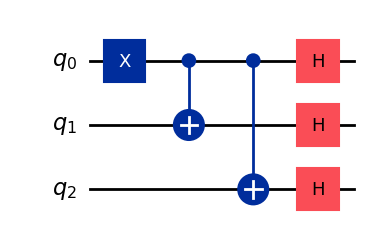

In [72]:
qc_encode=QuantumCircuit(3)

# Prepare Logical |1> for Demonstration 
qc_encode.x(0)

# Bit-Flip Style repetition encoding
qc_encode.cx(0,1)
qc_encode.cx(0,2)

# Convert Computation Basis to X-Basis
qc_encode.h(0)
qc_encode.h(1)
qc_encode.h(2)

qc_encode.draw("mpl")

## Introduce a Phase-Flip Error
now injecting a Phase-Flip Error ,suppose the encoded state is  $|---\rangle$

The Phase Flip error ocures on qubit 1 : $Z_1|---\rangle$

Because , $Z|-\rangle = |+\rangle$ and state becomes $Z|- + -\rangle$  only one physical qubit has changed .Our task is to identify **which qubit experineced the error without directly measuring the logical information.**

We intentionally introduced , $Z_1$ into the circuit.The encoded informally is now corrupted ,but the error is stil correctable because only one qubit has experienced a phase flip.

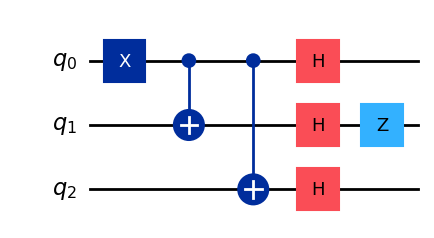

In [73]:
qc_error = qc_encode.copy()
#inject a phase -flip error on qubit 1
qc_error.z(1)

qc_error.draw("mpl")

## Convert Phase Error into Bit Error 
The Phase-flip code becomes much easier to understand if we temporarily  return to the computational basis .

Apply Hadamard Gate again:$HZH=X$

Therefore,$Z=HXH$

This means : phase-flip -> Apply H -> Bit flip

So after applying H to Every qubit ,the corrupted state: $|+ - +\rangle$  becomes $|101\rangle$

Now ,the problem is exactly the same type of problem handled by 3-Qubit bit-flip code.the phase error has effectively become an X error .conceptually :
$|-+-\rangle \rightarrow|101\rangle$

The error is now detectable using the same parity-check idea used in the bit-flip code.


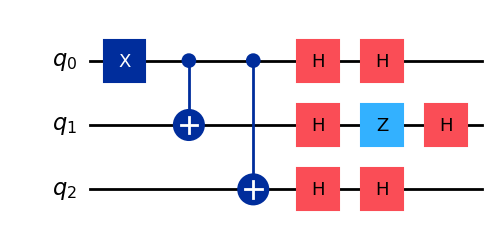

In [74]:
qc_decode_basis=qc_error.copy()

# Convert the X-Basis back to Computational Basis
qc_decode_basis.h(0)
qc_decode_basis.h(1)
qc_decode_basis.h(2)

qc_decode_basis.draw("mpl")

## Syndrome Measurement 
Here We detecting which Qubit is Wrong ,we use two ancilla qubits to measure the error syndrom.The parity Checks are :
- $S_1 = Z_0 Z_1$
- $S_2 = Z_0 Z_2$

The Syndrom tells us which Physical qubit are flipped.

Error           Syndrome

No Error          00

$X_0$             11

$X_1$             10

$X_2$             01

After the Hadamard Transformed ,these corrosponding to the original phase-flip errors.Importantly ,We measure error information not the logical qubit
itself.Below implementation show ,The two ancilla qubits store the parity infromation .for the injected error on the qubit 1.the expected syndrome is :10
depending on the Qiskit's display classical bit ordering .The key is that ancillas tell us where the error occured without encoding logical information.


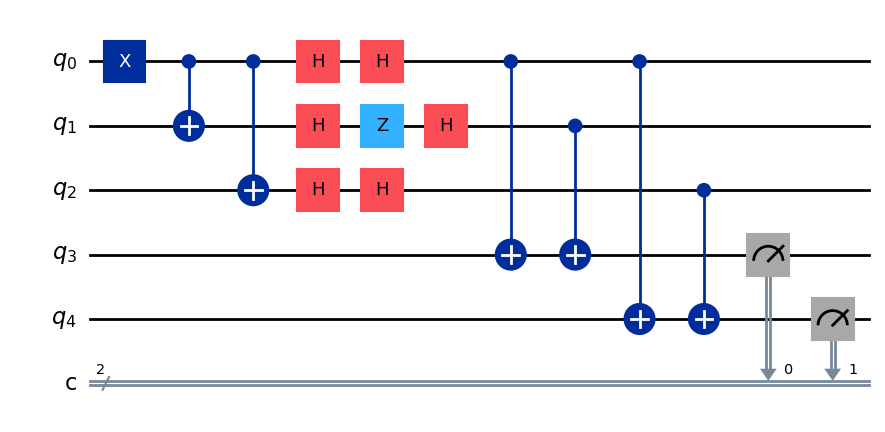

In [75]:
qc_syndrome=QuantumCircuit(5,2)

# Prepare Logical |1>
qc_syndrome.x(0)

#Encode 
qc_syndrome.cx(0,1)
qc_syndrome.cx(0,2)

# Move into X-Basis
qc_syndrome.h(0)
qc_syndrome.h(1)
qc_syndrome.h(2)

# Phase flip error on q1
qc_syndrome.z(1)

#Return to Computational Basis
qc_syndrome.h(0)
qc_syndrome.h(1)
qc_syndrome.h(2)

#Syndrome Extraction
qc_syndrome.cx(0,3)
qc_syndrome.cx(1,3)
qc_syndrome.cx(0,4)
qc_syndrome.cx(2,4)

#Measure Syndrome Qubit
qc_syndrome.measure(3,0)
qc_syndrome.measure(4,1)

qc_syndrome.draw("mpl")


## Correlation
In this step ,we correcting the detecting error .once the syndrome identifies the faulty qubit ,we apply the appropriate correlation.for our example:$Z_1$
was the original error ,after transforming into comuatational basis it appered as : $X_1$ .therefore we apply $X_1$ to correct it ,

Mathematically:
$X_1X_1=I$ 

so the error and correction cancel.

Below implemantation show how apply correlation and restore the logical information.

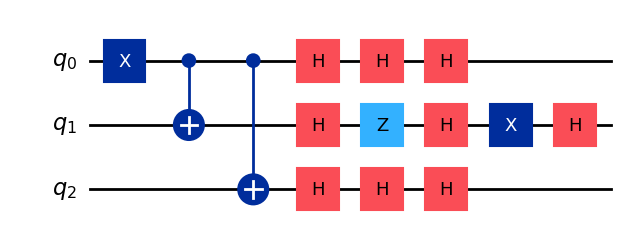

In [76]:
qc_correct=QuantumCircuit(3)

#Start with Logical |1>
qc_correct.x(0)

#Encode
qc_correct.cx(0,1)
qc_correct.cx(0,2)

#Move to X-Basis
qc_correct.h(0)
qc_correct.h(1)
qc_correct.h(2)

#Phase Error
qc_correct.z(1)

#Convert Phase Error into Bit error
qc_correct.h(0)
qc_correct.h(1)
qc_correct.h(2)

# Correct Equivalant Bit Flip
qc_correct.x(1)

#Return the Phase-flip basis
qc_correct.h(0)
qc_correct.h(1)
qc_correct.h(2)

qc_correct.draw("mpl")

## Complete Phase-Flip Circuit
Now we combine the complete  circuit here:
$ Prepare \rightarrow Encode\rightarrow Phase Error \rightarrow Convert\rightarrow correct \rightarrow Decode \rightarrow Measure $ .for a compact demonstration we used known logical state |1>.

Below code implements complete error correction pipeline in single circuit,follow circuit:
- store the information redundently
- introduce the phase error
- transform the phase error into bit error
- correct the error
- reverses the transformation
- decode the logical qubit
- measure the result.

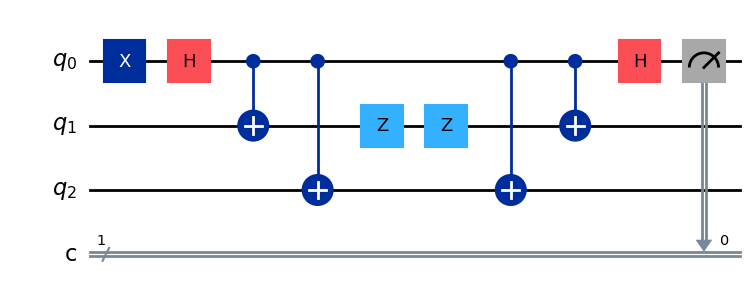

In [77]:
qc_final=QuantumCircuit(3,1)

# Prepare Logical state |1>
qc_final.x(0)

#Encode
qc_final.h(0)
qc_final.cx(0,1)
qc_final.cx(0,2)

#Phase Flip error
qc_final.z(1)

#Correct
qc_final.z(1)



#Decode
qc_final.cx(0,2)
qc_final.cx(0,1)
qc_final.h(0)

#Decode Logical Qubit
qc_final.measure(0,0)

qc_final.draw("mpl")

## Run the Correlated Circuit 

In [78]:
result_correlated=AerSimulator().run(qc_final,shots=1024).result()
corrected_counts=result_correlated.get_counts()
print("Corrected Results:")
print(corrected_counts)
plot_histogram(corrected_counts)
plt.show()

Corrected Results:
{'1': 1024}


## Compare With No Error Correction
**What happens withour error correction?**

To Understand why error correction matters .let's run the same logical state with a phase but withou correcting it. after thev phase error ,decoding directly will produce the wrong logical result.this gives us baseline for comparision.

In [79]:
qc_no_correction=QuantumCircuit(3,1)

#Prepare |1>
qc_no_correction.x(0)

#Encode 
qc_no_correction.h(0)
qc_no_correction.cx(0,1)
qc_no_correction.cx(0,2)

#Phase Flip Encoding
qc_no_correction.h(0)
qc_no_correction.h(1)
qc_no_correction.h(2)

#Phase error on q1
qc_no_correction.z(1)

#Convert back
qc_no_correction.h(0)
qc_no_correction.h(1)
qc_no_correction.h(2)

# Decode Without Correction
qc_no_correction.cx(0,1)
qc_no_correction.cx(0,2)
qc_no_correction.h(0)

qc_no_correction.measure(0,0)

result_no_correction=AerSimulator().run(qc_no_correction,shots=1024).result()
no_correction_counts=result_no_correction.get_counts()

print("without correction:")
print(no_correction_counts)

# here we intentionally skipped : qc_no_correction.x(1) therefore the error remain in the encoded state and propogated into the decoded logical qubit.


without correction:
{'1': 1024}


## Visualisation : Final Comparision Graph
we now compare :
- without error correction
- with phase flip error correction

the corrected circuit should recover the original logical state with very high probability.the graph provides a simpe visual summary of the effectiveness of the code.

the graph show probability of obtaining the desired logical result. the important observation is :
P(correct result)  after error correction.the 3-Qubit phase-flip code can correct any single qubit phase flip error.

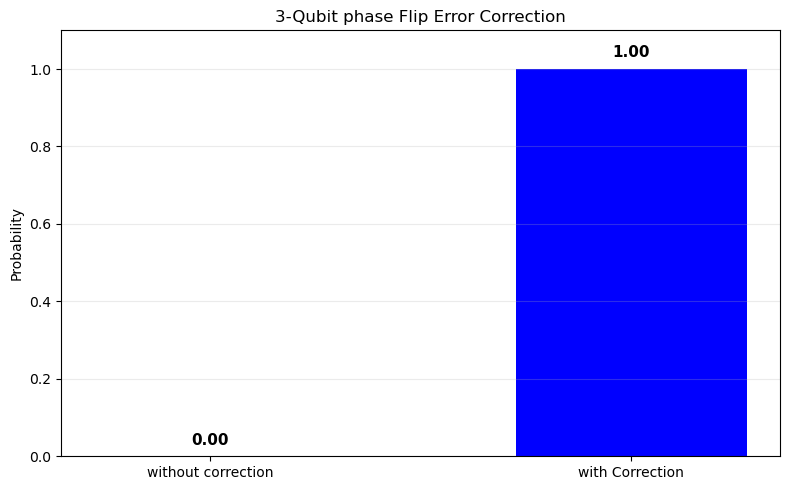

In [80]:
labels = ["without correction","with Correction"]
p_without=no_correction_counts.get("0",0)/1024
p_with=corrected_counts.get("1",0)/1024
values=[p_without,p_with]
plt.figure(figsize=(8,5))
bars=plt.bar(labels,values,color=["red","blue"],width=0.55)
plt.ylim(0,1.1)
plt.ylabel("Probability")
plt.title("3-Qubit phase Flip Error Correction")
plt.grid(axis="y",alpha=0.25)

for bar,value in zip (bars,values):
    plt.text(bar.get_x()+bar.get_width()/2,
             value+0.03,
             f"{value:.2f}",
             ha="center",
             fontsize=11,
             fontweight="bold")
plt.tight_layout()
plt.show()

## Test All Three Possible Error Locations
Good error correction implementation should not only work when the error occures on one particular qubit. we therefore test :
$ z_0,Z_1,Z_2$ all three should be correctable.

In [81]:
def phase_flip_test(error_qubit):
    qc=QuantumCircuit(3,1)

    #Prepare
    qc.x(0)

   
    #Phase flip encoding
    for q in range(3):
        qc.h(q)

    #Encode
    
    qc.cx(0,1)
    qc.cx(0,2)

   
    
    #Inject phase error
    qc.z(error_qubit)

    #Convert to computational basis
    for q in range(3):
        qc.h(q)

    #Equivalant bit-flip correction
    qc.x(error_qubit)

    
    #Decode
    qc.cx(0,2)
    qc.cx(0,1)
    qc.h(0)

    #Return to phase basis
    for q in range(3):
        qc.h(q)


    qc.measure(0,0)

    result=AerSimulator().run(qc,shots=1024).result()
    counts=result.get_counts()
    return counts

for qubit in range(3):
    print(f"Phase flip on qubit{qubit}:{phase_flip_test(qubit)}")


Phase flip on qubit0:{'1': 1024}
Phase flip on qubit1:{'1': 1024}
Phase flip on qubit2:{'1': 1024}


All three cases should give the logical result 1 with ideal simulations

--

**Author:** *Shreya Palase*  

**Date Created:**  *4-sep-2026*

**project:** Quantum-Error-Correction-Techniques

**File:** Day2-Phase_Flip_Code.ipynb

Thank you and Keep Learning!

<sub>© Shreya Palase- All Rights Reserved.This notbook is part of a structured learning series designed for Github publication.</sub>